In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
pd.set_option("display.float_format","{:,.2f}".format)


In [95]:
base_dir = Path.cwd()
print(base_dir)
df = pd.read_parquet(f'{base_dir}/files/sales.parquet')

c:\Users\practicanteit3\OneDrive - TRONEX S.A\Documentos\Proyectos\Market_Basket_Analysis


In [96]:
# setting the RFM to my clients
clientes = df.groupby('cliente').agg(
    montoventapesos = ('montoventapesos','sum'),
    frecuencia = ('factura', 'nunique'),
    recencia = ('fechafactura',lambda x: (pd.Timestamp.now()-x.max()).days)
).reset_index()


# First sight to the distribution of my data

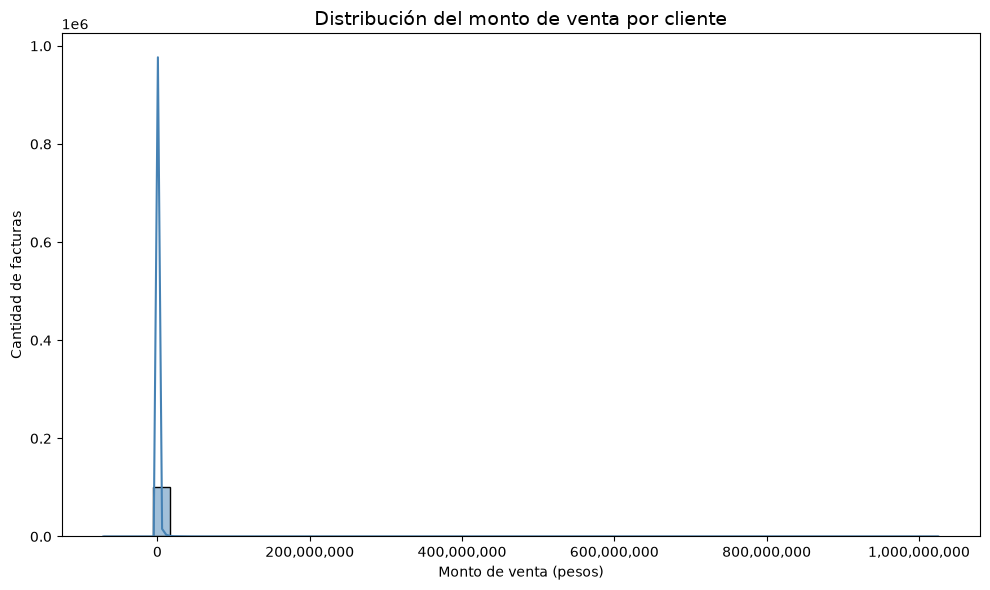

In [97]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=clientes,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=ax
)
ax.set_title('Distribución del monto de venta por cliente', fontsize=14)
ax.set_xlabel('Monto de venta (pesos)')
ax.set_ylabel('Cantidad de facturas')
#ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

> ***The data is skewed to the the right, so in this ocassion we are going to apply a log scale (I have done some researchs to look for it)***

In [98]:
devoluciones = clientes[clientes['montoventapesos']<=0]
clientes_positivos = clientes[clientes['montoventapesos']>0]


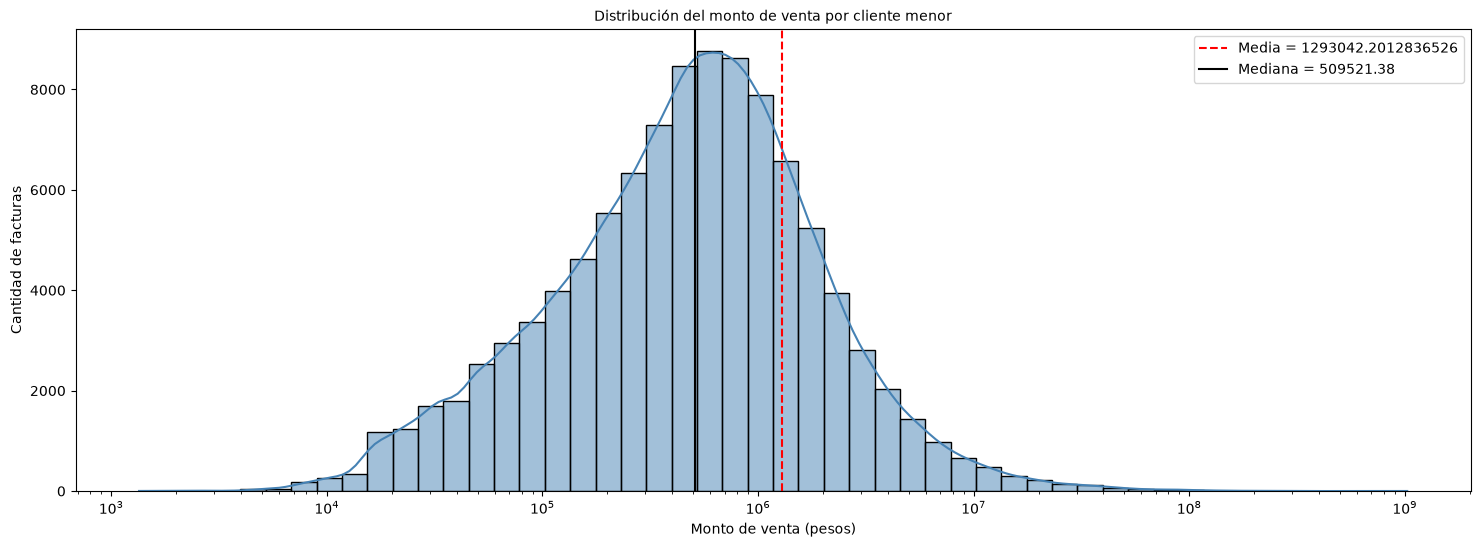

In [99]:
fig, axes = plt.subplots(figsize=(18, 6))
sns.histplot(
    data=clientes_positivos,
    x='montoventapesos',
    bins=50,
    kde=True,
    color='steelblue',
    ax=axes,
    log_scale=True
)

media = clientes_positivos['montoventapesos'].mean()
median = clientes_positivos['montoventapesos'].median() 
axes.set_title('Distribución del monto de venta por cliente menor', fontsize=10)
axes.set_xlabel('Monto de venta (pesos)')
axes.set_ylabel('Cantidad de facturas')
axes.axvline(media,label=f'Media = {media}', color= 'red',linestyle='--')
axes.axvline(median,label=f'Mediana = {median}', color= 'black',linestyle='-')
#axes[0].ticklabel_format(style='plain', axis='x')
#axes.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes.legend()

# **Machine Learning**
---

## Escalar los datos

In [133]:
from sklearn.preprocessing import QuantileTransformer

variables = ['frecuencia','recencia','montoventapesos']


x = clientes_positivos[variables].values
x_scaled = QuantileTransformer(output_distribution='normal', random_state=42).fit_transform(x)

x_scaled[:,0] = x_scaled[:,0]*2
x_scaled[:,1] = x_scaled[:,1]*4
x_scaled[:,2] = x_scaled[:,2]*3
 


> Take into account the a ***log10*** for 0 y ***-inf*** so it gives and error

In [101]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

x_pca = pca.fit_transform(x_scaled)

clientes_positivos['pca1'] = x_pca[:,0]
clientes_positivos['pca2'] = x_pca[:,1]


pd.DataFrame(
    data=pca.components_,
    columns=variables,
    index=['PCA1','PCA2']
)




,frecuencia,recencia,montoventapesos
PCA1,-0.46,0.79,-0.40
PCA2,0.60,0.61,0.51


<Axes: xlabel='pca1', ylabel='pca2'>

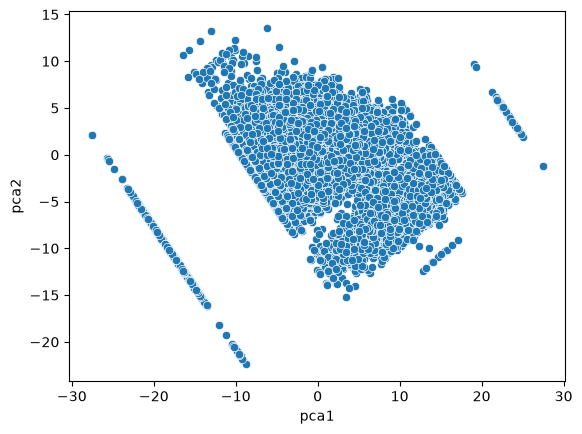

In [102]:
plt.Figure(figsize=(10,14))
sns.scatterplot(
    data=clientes_positivos,
    x=clientes_positivos['pca1'],
    y=clientes_positivos['pca2']
)

In [103]:
clientes_positivos

,cliente,montoventapesos,frecuencia,recencia,pca1,pca2
0,1000000422,"270,879.98",15,35,-0.69,-0.69
1,10000008,"223,311.98",2,14,-1.96,-4.70
2,1000002095,"57,641.61",3,440,5.87,-0.14
3,1000005315,"489,502.39",16,33,-1.45,-0.09
4,1000005684,"27,395.00",1,461,10.41,-5.89
...,...,...,...,...,...,...
102310,999371,"1,640,421.70",36,26,-4.84,2.58
102311,9994156,"1,134,201.23",17,74,-0.44,2.50
102312,9994575,"28,643,316.72",40,67,-4.70,7.53
102313,9994913,"20,855,275.80",39,11,-10.35,2.72


## ***Clustering***

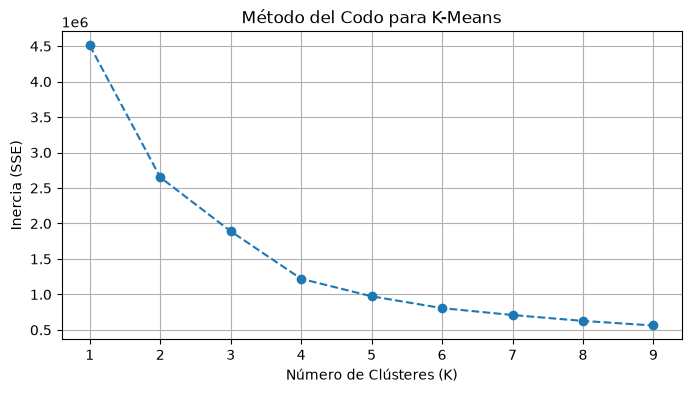

In [134]:
from sklearn.cluster import KMeans

inertia = []
rango = range(1,10)

valores = x_scaled
for i in rango:
    k_means = KMeans(n_clusters=i,random_state=42, n_init=10)
    k_means.fit(valores)
    inertia.append(k_means.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia (SSE)')
plt.title('Método del Codo para K-Means')
plt.grid(True)
plt.show()


> Para este tema use un **K_optimo = 3**

In [136]:
K_means= KMeans(n_clusters=4,random_state=42, n_init=1000).fit(valores)

datos = K_means.transform(valores)
print(K_means.cluster_centers_)
clientes_positivos['cluster'] = K_means.labels_

[[  1.33872668  -2.65976189   1.97865191]
 [ -0.89907807   2.67392872  -1.3569495 ]
 [  1.40288318 -20.79735033   1.89972849]
 [-10.39664351   4.8856005   -4.90956755]]


In [137]:
centroides = K_means.cluster_centers_

plt.Figure(figsize=(10,14))

centroides_x = centroides[:, 0]  # Primera columna (Eje X)
centroides_y = centroides[:, 1]  # Segunda columna (Eje Y)

# 3. Superponer los centroides sobre el gráfico
plt.scatter(
    centroides_x,
    centroides_y,
    color="black",  # Color contrastante
    s=250,  # Tamaño grande para destacar
    marker="X",  # Forma de 'X' o '*' para ver claramente el centro
    edgecolor="white",  # Borde blanco alrededor del marcador
    linewidth=1.5,
    label="Centroides",
    zorder=10,  # Mantiene los centroides al frente
)
sns.scatterplot(
    data=clientes_positivos,
    x='pca1',
    y='pca2',
    hue= 'cluster'
)

plt.xlabel('pca1: frecuencia + montoventapesos')
plt.ylabel('pca2: recencia + frecuencia + montoventapesos')
plt.legend(loc = 'upper right')


Error in callback <function flush_figures at 0x000001A849217ED0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

### Mezclar los clusters con su respectivo cliente

In [138]:
df_clientes = pd.merge(clientes_positivos[['cliente','cluster']],df, left_on='cliente', right_on='cliente', how='inner')

In [108]:
df_clientes.columns

Index(['cliente', 'cluster', 'factura', 'nombrecliente', 'fechafactura',
       'cantxunmedida', 'almacen', 'referencia', 'nombrereferencia',
       'cantidad', 'preciounitario', 'costounitario', 'montoventapesos',
       'costoventapesos', 'unidadnegocios', 'centrocostos', 'troevendedor',
       'troenombrevendedor', 'grouptat', 'lineatat', 'tro_e_marca', 'ruta',
       'porcentajedescuento', 'valordescuento', 'margenpesos',
       'porcentajemargen', 'zona_pais', 'zona_pais_gastos', 'canal', 'zona',
       'ciclo', 'obsequio'],
      dtype='str')

In [109]:
df_clientes.referencia.nunique()

494

In [128]:
clientes_positivos

,cliente,montoventapesos,frecuencia,recencia,pca1,pca2,cluster
0,1000000422,"270,879.98",15,35,-0.69,-0.69,1
1,10000008,"223,311.98",2,14,-1.96,-4.70,1
2,1000002095,"57,641.61",3,440,5.87,-0.14,0
3,1000005315,"489,502.39",16,33,-1.45,-0.09,1
4,1000005684,"27,395.00",1,461,10.41,-5.89,2
...,...,...,...,...,...,...,...
102310,999371,"1,640,421.70",36,26,-4.84,2.58,1
102311,9994156,"1,134,201.23",17,74,-0.44,2.50,1
102312,9994575,"28,643,316.72",40,67,-4.70,7.53,1
102313,9994913,"20,855,275.80",39,11,-10.35,2.72,1


In [139]:
values=  df_clientes.groupby('cluster').agg(
    clientes = ('cliente','nunique'),
    venta_promedio = ('montoventapesos','mean'),
    referencias_unicas = ('referencia','nunique')
).reset_index()

recencia_cluster = clientes_positivos.groupby('cluster').agg({
    'recencia':'mean',
    'frecuencia':'mean'
}).reset_index()

values = values.merge(recencia_cluster,on='cluster', how='inner')
values

,cluster,clientes,venta_promedio,referencias_unicas,recencia,frecuencia
0,0,49138,"39,971.05",483,30.65,21.56
1,1,42541,"24,653.09",447,261.84,7.99
2,2,2236,"38,660.03",378,8.00,23.01
3,3,8328,"33,857.18",343,478.10,1.00


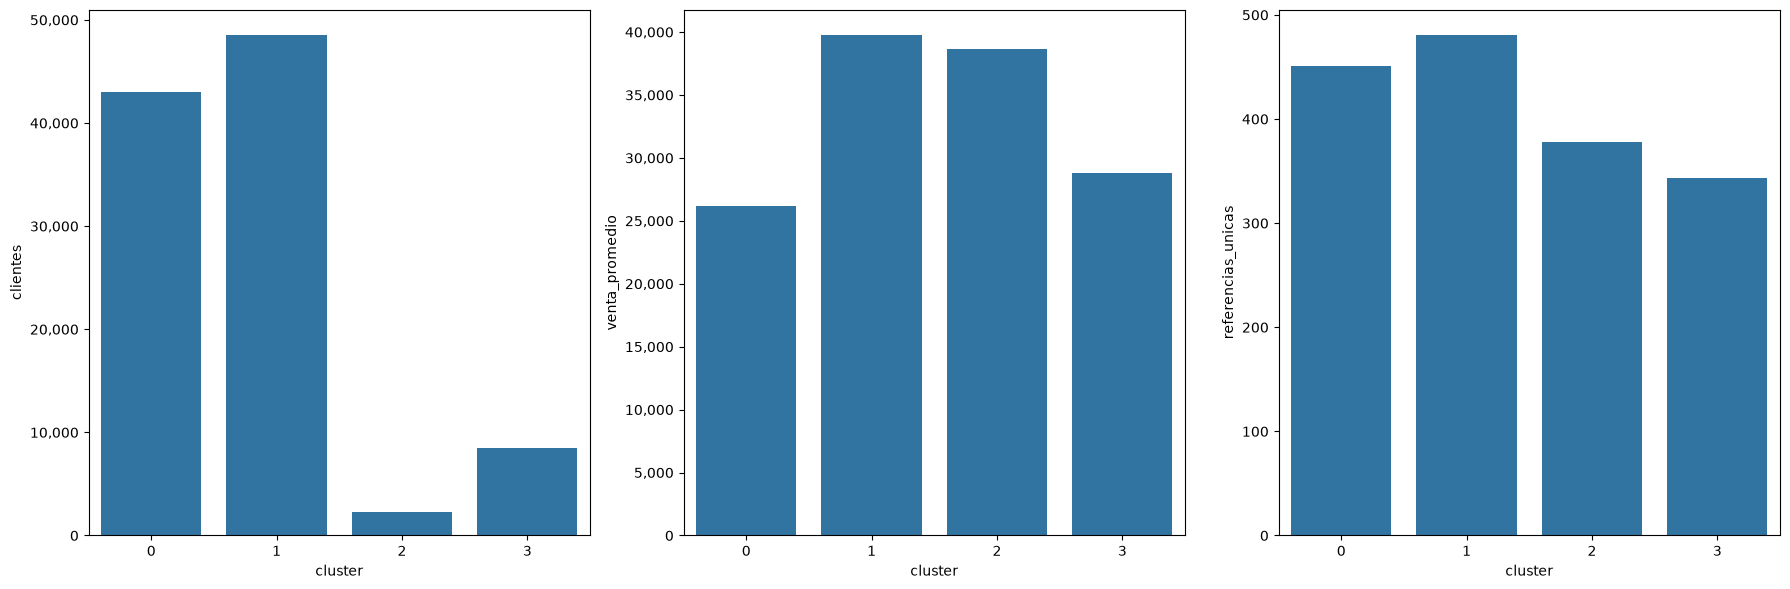

In [112]:
import matplotlib.ticker as ticker
fig, axes=plt.subplots(nrows=1, ncols=3, figsize = (18,6))


sns.barplot(
    data=values,
    x='cluster',
    y= 'clientes',
    ax=axes[0]
)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

sns.barplot(
    data=values,
    x='cluster',
    y= 'venta_promedio',
    ax=axes[1]
)
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

sns.barplot(
    data=values,
    x='cluster',
    y= 'referencias_unicas',
    ax=axes[2]
)
axes[2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### Análisis Visual de los Clústeres

A continuación, realizamos un análisis detallado de las dimensiones RFM (Recencia, Frecuencia y Monto) para cada uno de los clústeres identificados, permitiéndonos caracterizar el comportamiento de cada grupo de clientes.

C:\Users\practicanteit3\AppData\Local\Temp\ipykernel_7792\351941208.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\practicanteit3\AppData\Local\Temp\ipykernel_7792\351941208.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\practicanteit3\AppData\Local\Temp\ipykernel_7792\351941208.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


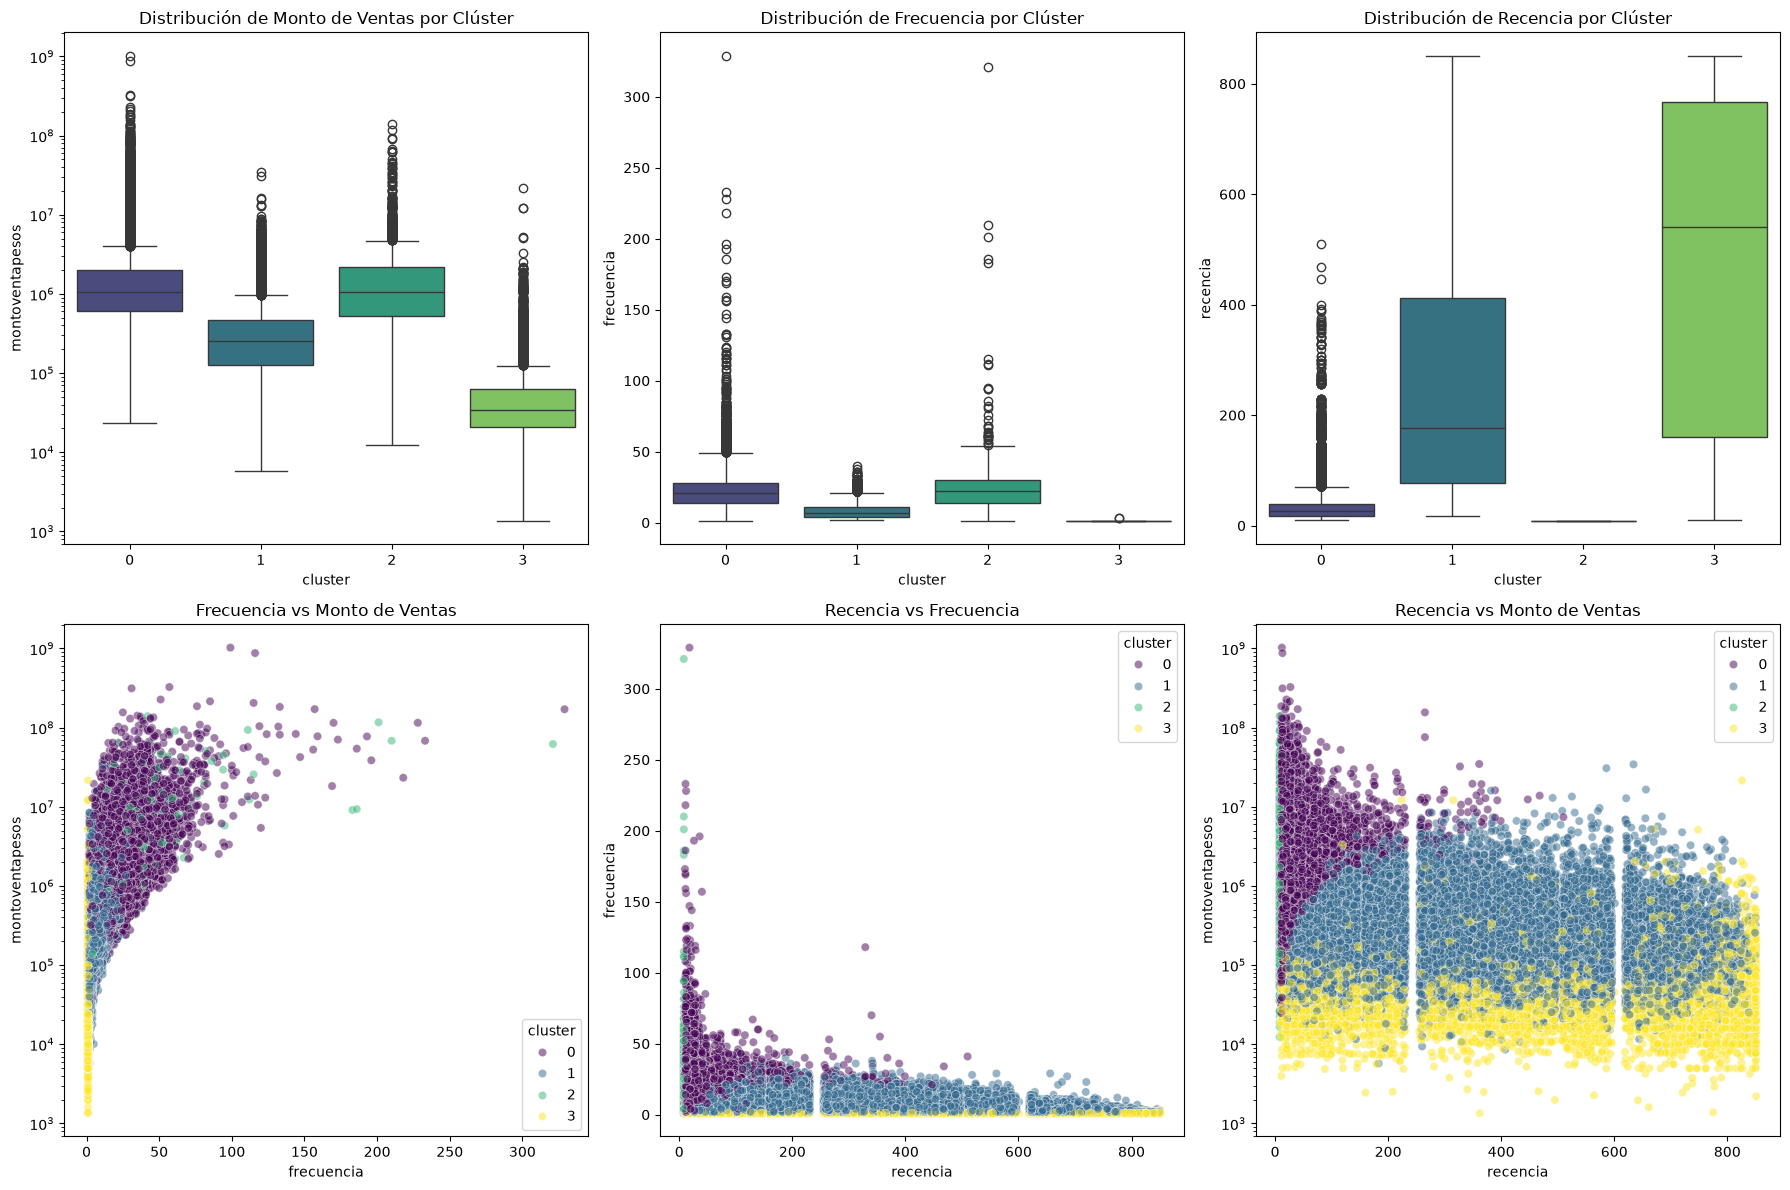

In [140]:
import matplotlib.ticker as ticker

# Crear una figura con múltiples subplots para analizar las dimensiones RFM por clúster
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))

# 1. Boxplot de Monto de Ventas por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='montoventapesos', 
    ax=axes[0, 0], 
    palette='viridis'
)
axes[0, 0].set_title('Distribución de Monto de Ventas por Clúster')
axes[0, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[0,0].set_yscale('log')

# 2. Boxplot de Frecuencia por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='frecuencia', 
    ax=axes[0, 1], 
    palette='viridis'
)
axes[0, 1].set_title('Distribución de Frecuencia por Clúster')

# 3. Boxplot de Recencia por Clúster
sns.boxplot(
    data=clientes_positivos, 
    x='cluster', 
    y='recencia', 
    ax=axes[0, 2], 
    palette='viridis'
)
axes[0, 2].set_title('Distribución de Recencia por Clúster')

# 4. Scatter Plot: Frecuencia vs Monto de Ventas
sns.scatterplot(
    data=clientes_positivos, 
    x='frecuencia', 
    y='montoventapesos', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 0], 
    alpha=0.5
)
axes[1, 0].set_title('Frecuencia vs Monto de Ventas')
axes[1, 0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[1, 0].set_yscale('log')

# 5. Scatter Plot: Recencia vs Frecuencia
sns.scatterplot(
    data=clientes_positivos, 
    x='recencia', 
    y='frecuencia', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 1], 
    alpha=0.5
)
axes[1, 1].set_title('Recencia vs Frecuencia')

# 6. Scatter Plot: Recencia vs Monto de Ventas
sns.scatterplot(
    data=clientes_positivos, 
    x='recencia', 
    y='montoventapesos', 
    hue='cluster', 
    palette='viridis', 
    ax=axes[1, 2], 
    alpha=0.5
)
axes[1, 2].set_title('Recencia vs Monto de Ventas')
axes[1, 2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
axes[1, 2].set_yscale('log')

plt.tight_layout()
plt.show()

### ***Clients understanding***

I visualized every cluster with his own different color to see how they behave inside the clusters, and I found that they share some characteristics that are very important to take into acount


In [144]:
clientes_positivos[(clientes_positivos['cluster']==2) & (clientes_positivos['frecuencia']==1)].sort_values(by='frecuencia', ascending=True)

,cliente,montoventapesos,frecuencia,recencia,pca1,pca2,cluster
6643,1020744805,"16,664.97",1,8,-9.11,-21.94,2
10269,1036613623,"26,470.50",1,8,-9.60,-21.31,2
12199,1041228884,"84,705.84",1,8,-10.43,-20.24,2
17023,1066184022,"79,411.50",1,8,-10.38,-20.30,2
25876,1111753352,"659,125.66",1,8,-12.04,-18.17,2
26336,1115741467,"56,302.45",1,8,-10.16,-20.58,2
27048,1121296778,"35,294.12",1,8,-9.84,-21.00,2
32478,13719857,"83,815.01",1,8,-10.42,-20.25,2
33893,15325091,"52,941.00",1,8,-10.13,-20.63,2
38257,20500146,"22,689.06",1,8,-9.41,-21.55,2


In [145]:
clientes_positivos[(clientes_positivos['cluster']==3) & (clientes_positivos['frecuencia']==1)].sort_values(by='frecuencia', ascending=True)

,cliente,montoventapesos,frecuencia,recencia,pca1,pca2,cluster
4,1000005684,"27,395.00",1,461,10.41,-5.89,3
17,1000031470,"231,428.20",1,81,6.25,-5.98,3
23,1000049577,"22,407.78",1,55,7.26,-8.77,3
27,1000062545,"24,610.92",1,200,9.13,-7.10,3
30,1000063542,"18,649.46",1,60,7.60,-8.88,3
...,...,...,...,...,...,...,...
102205,98761886,"217,857.10",1,728,10.89,-2.52,3
102222,98766400,"31,260.48",1,791,13.25,-3.53,3
102257,9922060,"16,302.60",1,365,10.48,-6.98,3
102275,9956393,"98,630.28",1,840,13.94,-1.33,3


In [116]:
df_clientes.head()

,cliente,cluster,factura,nombrecliente,fechafactura,cantxunmedida,almacen,referencia,nombrereferencia,cantidad,...,porcentajedescuento,valordescuento,margenpesos,porcentajemargen,zona_pais,zona_pais_gastos,canal,zona,ciclo,obsequio
0,1000000422,1,HHBO001232706,MARIA ANYELI ROMAN VILLA,2026-02-23,1,BG25,YATIJEROM,TIJERA PUNTA ROMA ECONOMICA,6,...,0.00,0.00,867.37,0.17,ZONA BOGOTA,ZONA BOGOTA,TAT,918,A,0
1,1000000422,1,HHBO001232706,MARIA ANYELI ROMAN VILLA,2026-02-23,1,BG25,YAPANIAZUX12,PAÑITOS HUMEDOS DAMPY AAZUL X 12UND,6,...,0.00,0.00,"1,338.00",0.26,ZONA BOGOTA,ZONA BOGOTA,TAT,918,A,0
2,1000000422,1,HHBO001232706,MARIA ANYELI ROMAN VILLA,2026-02-23,0,BG25,DRSERUNSILISACHETX1,SERUM DE SILICONA DROMATIC EN SACHET X1,2,...,0.00,0.00,930.18,0.23,ZONA BOGOTA,ZONA BOGOTA,TAT,918,A,0
3,1000000422,1,HHBO001299482,MARIA ANYELI ROMAN VILLA,2026-06-17,1,BG25,YACAN25,CANDADO 25 MM,5,...,0.00,0.00,"1,708.53",0.21,ZONA BOGOTA,ZONA BOGOTA,TAT,918,A,0
4,1000000422,1,HHBO001018635,MARIA ANYELI ROMAN VILLA,2025-02-24,2,BG25,LYGUANT8AMX2,LIMPIAYA GUANTE TALLA8 AMARILLO X2,1,...,0.00,0.00,484.30,0.16,ZONA BOGOTA,ZONA BOGOTA,TAT,918,A,0
